# Surface Air CO2 Sensor Workbench

Surface air CO2 sensor from `variables_schema.xlsx` for the same 4-sensor vertical:

- slope: `LEO West`
- basalt x: `-1`
- basalt y: `18`
- air x: `0`
- air y: `17`
- ideal period for this 4-sensor vertical: `2024-07-10 13:00:00` to `2024-07-29 14:15:00`
- ideal-period step: `15 min`
- ideal-period duration: `19.05 days`
- comparison basis: air uses `last known value` only while the last real air observation is not older than `90 min`
- air freshness rule: `1.5 * modal air step = 1.5 * 60 min = 90 min`
- height: `25 cm above surface`
- table: `leo_west.datavalueslicor`
- sensorid: `1289`
- variableid: `56`
- sensor code: `LEO-W_17_0_1_LI-7000`


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path


def _ensure_sensordb_dir_on_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / 'Project_description' / 'sensorDB',
    ]
    for candidate in candidates:
        if (candidate / 'basalt_co2_series.py').exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    raise ModuleNotFoundError(f'Could not locate sensorDB module directory from {cwd}.')


SENSORDB_DIR = _ensure_sensordb_dir_on_path()

from air_co2_series import AirCO2Series

IDEAL_START = pd.Timestamp('2024-07-10 13:00:00')
IDEAL_END = pd.Timestamp('2024-07-29 14:15:00')
IDEAL_STEP = '15min'
IDEAL_INDEX = pd.date_range(IDEAL_START, IDEAL_END, freq=IDEAL_STEP)
AIR_MODAL_STEP_MIN = 60
AIR_FRESHNESS_MIN = 90
AIR_FRESHNESS = pd.Timedelta(minutes=AIR_FRESHNESS_MIN)

def align_air_last_known_with_freshness(series: pd.Series, target_index: pd.DatetimeIndex) -> pd.DataFrame:
    air_frame = (
        series.sort_index()
        .rename('datavalue')
        .rename_axis('air_ts')
        .reset_index()
    )
    target = pd.DataFrame({'ts': target_index})
    aligned = pd.merge_asof(
        target,
        air_frame,
        left_on='ts',
        right_on='air_ts',
        direction='backward',
        tolerance=AIR_FRESHNESS,
    )
    aligned['air_age_min'] = (aligned['ts'] - aligned['air_ts']).dt.total_seconds().div(60)
    return aligned

air_sensor_25cm = AirCO2Series(
    table_name='leo_west.datavalueslicor',
    sensor_id=1289,
    variable_id=56,
    slope='LEO West',
    x_coord_m=0,
    y_coord_m=17,
    height_m=0.25,
    sensor_code='LEO-W_17_0_1_LI-7000',
)

air_sensor_25cm


AirCO2Series(table_name='leo_west.datavalueslicor', sensor_id=1289, variable_id=56, slope='LEO West', x_coord_m=0, y_coord_m=17, height_m=0.25, units='ppm', sensor_code='LEO-W_17_0_1_LI-7000')

In [2]:
coverage_air_25cm = air_sensor_25cm.describe_time_coverage()
raw_air_series_25cm = air_sensor_25cm.fetch_series(start_datetime='2023-07-01')
ideal_air_alignment_25cm = align_air_last_known_with_freshness(raw_air_series_25cm, IDEAL_INDEX)
ideal_air_series_25cm = ideal_air_alignment_25cm.set_index('ts')['datavalue']
raw_air_points_25cm = raw_air_series_25cm.loc[IDEAL_START - AIR_FRESHNESS:IDEAL_END]

display(coverage_air_25cm)
display(ideal_air_alignment_25cm.head())
display(ideal_air_alignment_25cm.tail())
print(f'Raw air rows fetched: {len(raw_air_series_25cm):,}')
print(f'Ideal-period aligned rows: {len(ideal_air_series_25cm):,}')
print(f'Aligned rows with real supporting air observation: {ideal_air_series_25cm.notna().sum():,}')
print(f'Max air age used inside ideal period: {ideal_air_alignment_25cm["air_age_min"].max():.2f} min')


{'first_timestamp': Timestamp('2023-07-08 17:36:32'),
 'last_timestamp': Timestamp('2026-04-05 20:03:46'),
 'table_name': 'leo_west.datavalueslicor',
 'sensor_id': 1289,
 'sensor_code': 'LEO-W_17_0_1_LI-7000',
 'variable_id': 56,
 'slope': 'LEO West',
 'x_coord_m': 0,
 'y_coord_m': 17,
 'height_m': 0.25,
 'units': 'ppm'}

,ts,air_ts,datavalue,air_age_min
0,2024-07-10 13:00:00,2024-07-10 12:53:06,448.3,6.9
1,2024-07-10 13:15:00,2024-07-10 12:53:06,448.3,21.9
2,2024-07-10 13:30:00,2024-07-10 12:53:06,448.3,36.9
3,2024-07-10 13:45:00,2024-07-10 12:53:06,448.3,51.9
4,2024-07-10 14:00:00,2024-07-10 13:52:06,443.1,7.9


,ts,air_ts,datavalue,air_age_min
1825,2024-07-29 13:15:00,2024-07-29 12:55:32,442.0,19.466667
1826,2024-07-29 13:30:00,2024-07-29 12:55:32,442.0,34.466667
1827,2024-07-29 13:45:00,2024-07-29 12:55:32,442.0,49.466667
1828,2024-07-29 14:00:00,2024-07-29 12:55:32,442.0,64.466667
1829,2024-07-29 14:15:00,2024-07-29 12:55:32,442.0,79.466667


Raw air rows fetched: 10,743
Ideal-period aligned rows: 1,830
Aligned rows with real supporting air observation: 1,830
Max air age used inside ideal period: 80.58 min


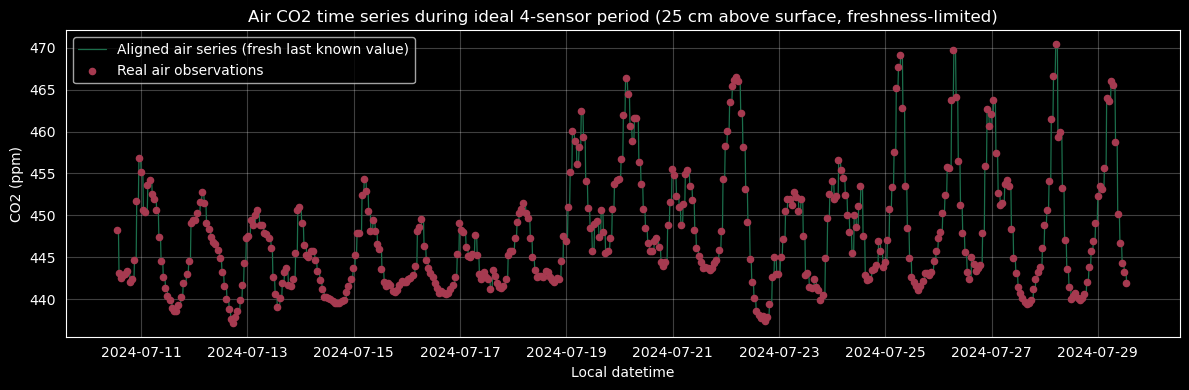

In [3]:
ideal_air_series_25cm = ideal_air_series_25cm.mask(ideal_air_series_25cm <= 0)
figure, axis = plt.subplots(figsize=(12, 4))
axis.plot(
    ideal_air_series_25cm.index,
    ideal_air_series_25cm.to_numpy(copy=False),
    color='#1B6E4B',
    linewidth=0.9,
    label='Aligned air series (fresh last known value)',
)
axis.scatter(
    raw_air_points_25cm.index,
    raw_air_points_25cm.to_numpy(copy=False),
    color='#A63A50',
    s=20,
    zorder=3,
    label='Real air observations',
)
axis.set_xlabel('Local datetime')
axis.set_ylabel('CO2 (ppm)')
axis.set_title('Air CO2 time series during ideal 4-sensor period (25 cm above surface, freshness-limited)')
axis.grid(True, alpha=0.25)
axis.legend(loc='best')
figure.tight_layout()
# Example: inspect a narrower date range inside the ideal period.
# zoom_start = pd.Timestamp('2024-07-15 00:00:00')
# zoom_end = pd.Timestamp('2024-07-20 12:00:00')
# zoom_series = ideal_air_series_25cm.loc[zoom_start:zoom_end]
# zoom_points = raw_air_points_25cm.loc[zoom_start - AIR_FRESHNESS:zoom_end]
# figure, axis = plt.subplots(figsize=(12, 4))
# axis.plot(zoom_series.index, zoom_series.to_numpy(copy=False), color='#1B6E4B', linewidth=0.9, label='Aligned air series (fresh last known value)')
# axis.scatter(zoom_points.index, zoom_points.to_numpy(copy=False), color='#A63A50', s=20, zorder=3, label='Real air observations')
# axis.set_xlabel('Local datetime')
# axis.set_ylabel('CO2 (ppm)')
# axis.set_title('Air CO2 time series for a narrower window (25 cm above surface, freshness-limited)')
# axis.grid(True, alpha=0.25)
# axis.legend(loc='best')
# figure.tight_layout()
plt.show()


# Basalt CO2 Sensor Workbench

Basalt sensor from `variables_schema.xlsx` for the 4-sensor vertical:

- slope: `LEO West`
- basalt x: `-1`
- basalt y: `18`
- air x: `0`
- air y: `17`
- ideal period for this 4-sensor vertical: `2024-07-10 13:00:00` to `2024-07-29 14:15:00`
- ideal-period step: `15 min`
- ideal-period duration: `19.05 days`
- comparison basis: basalt values are collapsed to `15-minute` slot means; air uses `last known value` only while air age is `<= 90 min`
- air freshness rule: `1.5 * modal air step = 1.5 * 60 min = 90 min`
- depth: `5 cm below surface`
- table: `leo_west.datavalues`
- sensorid: `1003`
- variableid: `9`
- sensor code: `LEO-W_18_-1_1_GMM222`


In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path


def _ensure_sensordb_dir_on_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / 'Project_description' / 'sensorDB',
    ]
    for candidate in candidates:
        if (candidate / 'basalt_co2_series.py').exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    raise ModuleNotFoundError(f'Could not locate sensorDB module directory from {cwd}.')


SENSORDB_DIR = _ensure_sensordb_dir_on_path()

from basalt_co2_series import BasaltCO2Series

IDEAL_START = pd.Timestamp('2024-07-10 13:00:00')
IDEAL_END = pd.Timestamp('2024-07-29 14:15:00')
IDEAL_STEP = '15min'

def collapse_to_slot_mean(frame: pd.DataFrame) -> pd.Series:
    return (
        frame.assign(
            localdatetime=pd.to_datetime(frame['localdatetime']),
            datavalue=pd.to_numeric(frame['datavalue'], errors='coerce'),
            slot_ts=lambda df: df['localdatetime'].dt.floor(IDEAL_STEP),
        )
        .groupby('slot_ts')['datavalue']
        .mean()
        .sort_index()
    )

sensor_5cm = BasaltCO2Series(
    table_name='leo_west.datavalues',
    sensor_id=1003,
    variable_id=9,
    slope='LEO West',
    x_coord_m=-1,
    y_coord_m=18,
    depth_cm=5,
)

sensor_5cm


BasaltCO2Series(table_name='leo_west.datavalues', sensor_id=1003, variable_id=9, slope='LEO West', x_coord_m=-1, y_coord_m=18, depth_cm=5, units='ppm')

In [5]:
coverage_5cm = sensor_5cm.describe_time_coverage()
frame_5cm = sensor_5cm.fetch_dataframe(start_datetime=IDEAL_START, end_datetime=IDEAL_END)
ideal_series_5cm = collapse_to_slot_mean(frame_5cm).loc[IDEAL_START:IDEAL_END]

display(coverage_5cm)
display(ideal_series_5cm.head())
display(ideal_series_5cm.tail())
print(f'Raw rows fetched inside ideal period: {len(frame_5cm):,}')
print(f'15-minute slot rows in ideal period: {len(ideal_series_5cm):,}')


{'first_timestamp': Timestamp('2013-09-11 12:00:00'),
 'last_timestamp': Timestamp('2026-04-05 21:30:01'),
 'table_name': 'leo_west.datavalues',
 'sensor_id': 1003,
 'variable_id': 9,
 'slope': 'LEO West',
 'x_coord_m': -1,
 'y_coord_m': 18,
 'depth_cm': 5,
 'units': 'ppm'}

slot_ts
2024-07-10 13:00:00    4990.414333
2024-07-10 13:15:00    4993.010426
2024-07-10 13:30:00    4989.012210
2024-07-10 13:45:00    4990.512943
2024-07-10 14:00:00    4993.574556
Name: datavalue, dtype: float64

slot_ts
2024-07-29 13:15:00    4989.045032
2024-07-29 13:30:00    4992.594258
2024-07-29 13:45:00    4991.411177
2024-07-29 14:00:00    4990.983963
2024-07-29 14:15:00    4991.734330
Name: datavalue, dtype: float64

Raw rows fetched inside ideal period: 1,830
15-minute slot rows in ideal period: 1,830


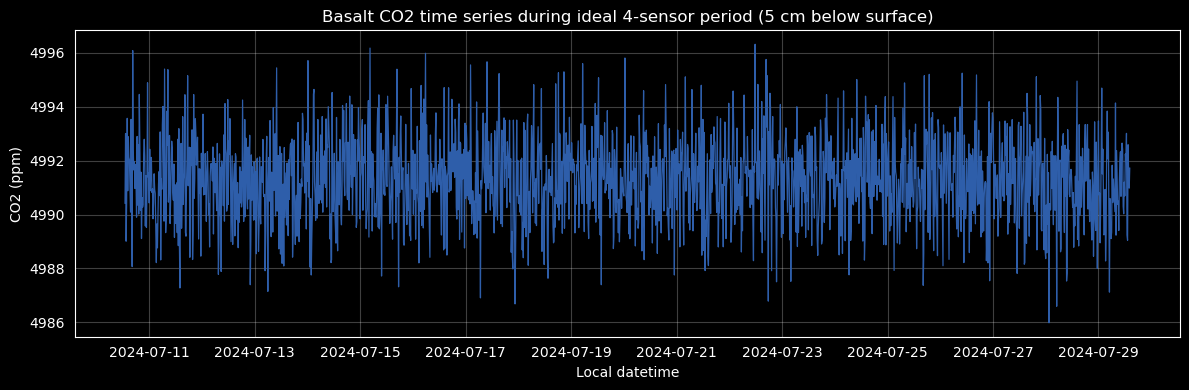

In [6]:
ideal_series_5cm = ideal_series_5cm.mask(ideal_series_5cm <= 0)
figure, axis = sensor_5cm.plot(
    series=ideal_series_5cm,
    title='Basalt CO2 time series during ideal 4-sensor period (5 cm below surface)',
)
# Example: inspect a narrower date range inside the ideal period.
# zoom_start = pd.Timestamp('2024-07-15 00:00:00')
# zoom_end = pd.Timestamp('2024-07-20 12:00:00')
# figure, axis = sensor_5cm.plot(
#     series=ideal_series_5cm.loc[zoom_start:zoom_end],
#     title='Basalt CO2 time series for a narrower window (5 cm below surface)',
# )
plt.show()


# Basalt CO2 Sensor Workbench

Basalt sensor from `variables_schema.xlsx` for the 4-sensor vertical:

- slope: `LEO West`
- basalt x: `-1`
- basalt y: `18`
- air x: `0`
- air y: `17`
- ideal period for this 4-sensor vertical: `2024-07-10 13:00:00` to `2024-07-29 14:15:00`
- ideal-period step: `15 min`
- ideal-period duration: `19.05 days`
- comparison basis: basalt values are collapsed to `15-minute` slot means; air uses `last known value` only while air age is `<= 90 min`
- air freshness rule: `1.5 * modal air step = 1.5 * 60 min = 90 min`
- depth: `20 cm below surface`
- table: `leo_west.datavalues`
- sensorid: `1019`
- variableid: `9`
- sensor code: `LEO-W_18_-1_2_GMM222`


In [7]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path


def _ensure_sensordb_dir_on_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / 'Project_description' / 'sensorDB',
    ]
    for candidate in candidates:
        if (candidate / 'basalt_co2_series.py').exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    raise ModuleNotFoundError(f'Could not locate sensorDB module directory from {cwd}.')


SENSORDB_DIR = _ensure_sensordb_dir_on_path()

from basalt_co2_series import BasaltCO2Series

IDEAL_START = pd.Timestamp('2024-07-10 13:00:00')
IDEAL_END = pd.Timestamp('2024-07-29 14:15:00')
IDEAL_STEP = '15min'

def collapse_to_slot_mean(frame: pd.DataFrame) -> pd.Series:
    return (
        frame.assign(
            localdatetime=pd.to_datetime(frame['localdatetime']),
            datavalue=pd.to_numeric(frame['datavalue'], errors='coerce'),
            slot_ts=lambda df: df['localdatetime'].dt.floor(IDEAL_STEP),
        )
        .groupby('slot_ts')['datavalue']
        .mean()
        .sort_index()
    )

sensor_20cm = BasaltCO2Series(
    table_name='leo_west.datavalues',
    sensor_id=1019,
    variable_id=9,
    slope='LEO West',
    x_coord_m=-1,
    y_coord_m=18,
    depth_cm=20,
)

sensor_20cm


BasaltCO2Series(table_name='leo_west.datavalues', sensor_id=1019, variable_id=9, slope='LEO West', x_coord_m=-1, y_coord_m=18, depth_cm=20, units='ppm')

In [8]:
coverage_20cm = sensor_20cm.describe_time_coverage()
frame_20cm = sensor_20cm.fetch_dataframe(start_datetime=IDEAL_START, end_datetime=IDEAL_END)
ideal_series_20cm = collapse_to_slot_mean(frame_20cm).loc[IDEAL_START:IDEAL_END]

display(coverage_20cm)
display(ideal_series_20cm.head())
display(ideal_series_20cm.tail())
print(f'Raw rows fetched inside ideal period: {len(frame_20cm):,}')
print(f'15-minute slot rows in ideal period: {len(ideal_series_20cm):,}')


{'first_timestamp': Timestamp('2013-09-11 12:00:00'),
 'last_timestamp': Timestamp('2026-04-05 21:30:01'),
 'table_name': 'leo_west.datavalues',
 'sensor_id': 1019,
 'variable_id': 9,
 'slope': 'LEO West',
 'x_coord_m': -1,
 'y_coord_m': 18,
 'depth_cm': 20,
 'units': 'ppm'}

slot_ts
2024-07-10 13:00:00    6974.066518
2024-07-10 13:15:00    6973.123261
2024-07-10 13:30:00    6972.065182
2024-07-10 13:45:00    6971.474803
2024-07-10 14:00:00    6974.350169
Name: datavalue, dtype: float64

slot_ts
2024-07-29 13:15:00    6971.965580
2024-07-29 13:30:00    6972.808946
2024-07-29 13:45:00    6974.994265
2024-07-29 14:00:00    6973.744437
2024-07-29 14:15:00    6974.495900
Name: datavalue, dtype: float64

Raw rows fetched inside ideal period: 1,830
15-minute slot rows in ideal period: 1,830


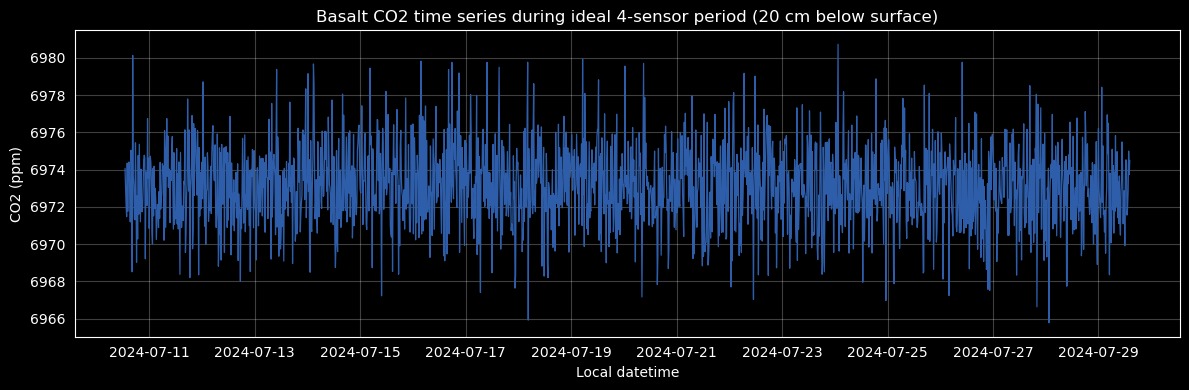

In [9]:
ideal_series_20cm = ideal_series_20cm.mask(ideal_series_20cm <= 0)
figure, axis = sensor_20cm.plot(
    series=ideal_series_20cm,
    title='Basalt CO2 time series during ideal 4-sensor period (20 cm below surface)',
)
# Example: inspect a narrower date range inside the ideal period.
# zoom_start = pd.Timestamp('2024-07-15 00:00:00')
# zoom_end = pd.Timestamp('2024-07-20 12:00:00')
# figure, axis = sensor_20cm.plot(
#     series=ideal_series_20cm.loc[zoom_start:zoom_end],
#     title='Basalt CO2 time series for a narrower window (20 cm below surface)',
# )
plt.show()


# Basalt CO2 Sensor Workbench

Basalt sensor from `variables_schema.xlsx` for the 4-sensor vertical:

- slope: `LEO West`
- basalt x: `-1`
- basalt y: `18`
- air x: `0`
- air y: `17`
- ideal period for this 4-sensor vertical: `2024-07-10 13:00:00` to `2024-07-29 14:15:00`
- ideal-period step: `15 min`
- ideal-period duration: `19.05 days`
- comparison basis: basalt values are collapsed to `15-minute` slot means; air uses `last known value` only while air age is `<= 90 min`
- air freshness rule: `1.5 * modal air step = 1.5 * 60 min = 90 min`
- depth: `35 cm below surface`
- table: `leo_west.datavalues`
- sensorid: `1030`
- variableid: `9`
- sensor code: `LEO-W_18_-1_3_GMM222`


In [10]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path


def _ensure_sensordb_dir_on_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / 'Project_description' / 'sensorDB',
    ]
    for candidate in candidates:
        if (candidate / 'basalt_co2_series.py').exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    raise ModuleNotFoundError(f'Could not locate sensorDB module directory from {cwd}.')


SENSORDB_DIR = _ensure_sensordb_dir_on_path()

from basalt_co2_series import BasaltCO2Series

IDEAL_START = pd.Timestamp('2024-07-10 13:00:00')
IDEAL_END = pd.Timestamp('2024-07-29 14:15:00')
IDEAL_STEP = '15min'

def collapse_to_slot_mean(frame: pd.DataFrame) -> pd.Series:
    return (
        frame.assign(
            localdatetime=pd.to_datetime(frame['localdatetime']),
            datavalue=pd.to_numeric(frame['datavalue'], errors='coerce'),
            slot_ts=lambda df: df['localdatetime'].dt.floor(IDEAL_STEP),
        )
        .groupby('slot_ts')['datavalue']
        .mean()
        .sort_index()
    )

sensor_35cm = BasaltCO2Series(
    table_name='leo_west.datavalues',
    sensor_id=1030,
    variable_id=9,
    slope='LEO West',
    x_coord_m=-1,
    y_coord_m=18,
    depth_cm=35,
)

sensor_35cm


BasaltCO2Series(table_name='leo_west.datavalues', sensor_id=1030, variable_id=9, slope='LEO West', x_coord_m=-1, y_coord_m=18, depth_cm=35, units='ppm')

In [11]:
coverage_35cm = sensor_35cm.describe_time_coverage()
frame_35cm = sensor_35cm.fetch_dataframe(start_datetime=IDEAL_START, end_datetime=IDEAL_END)
ideal_series_35cm = collapse_to_slot_mean(frame_35cm).loc[IDEAL_START:IDEAL_END]

display(coverage_35cm)
display(ideal_series_35cm.head())
display(ideal_series_35cm.tail())
print(f'Raw rows fetched inside ideal period: {len(frame_35cm):,}')
print(f'15-minute slot rows in ideal period: {len(ideal_series_35cm):,}')


{'first_timestamp': Timestamp('2013-09-11 12:00:00'),
 'last_timestamp': Timestamp('2026-04-05 21:30:01'),
 'table_name': 'leo_west.datavalues',
 'sensor_id': 1030,
 'variable_id': 9,
 'slope': 'LEO West',
 'x_coord_m': -1,
 'y_coord_m': 18,
 'depth_cm': 35,
 'units': 'ppm'}

slot_ts
2024-07-10 13:00:00    458.266541
2024-07-10 13:15:00    462.138726
2024-07-10 13:30:00    446.841714
2024-07-10 13:45:00    439.450067
2024-07-10 14:00:00    451.710717
Name: datavalue, dtype: float64

slot_ts
2024-07-29 13:15:00    510.138267
2024-07-29 13:30:00    510.176652
2024-07-29 13:45:00    516.303116
2024-07-29 14:00:00    512.637835
2024-07-29 14:15:00    523.334341
Name: datavalue, dtype: float64

Raw rows fetched inside ideal period: 1,830
15-minute slot rows in ideal period: 1,830


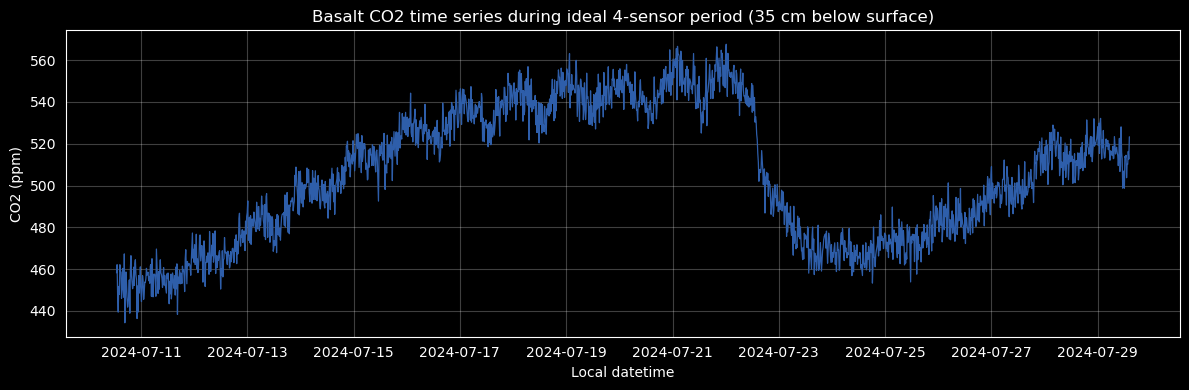

In [12]:
ideal_series_35cm = ideal_series_35cm.mask(ideal_series_35cm <= 0)
figure, axis = sensor_35cm.plot(
    series=ideal_series_35cm,
    title='Basalt CO2 time series during ideal 4-sensor period (35 cm below surface)',
)
# Example: inspect a narrower date range inside the ideal period.
# zoom_start = pd.Timestamp('2024-07-15 00:00:00')
# zoom_end = pd.Timestamp('2024-07-20 12:00:00')
# figure, axis = sensor_35cm.plot(
#     series=ideal_series_35cm.loc[zoom_start:zoom_end],
#     title='Basalt CO2 time series for a narrower window (35 cm below surface)',
# )
plt.show()
